<a href="https://colab.research.google.com/github/gustavbieder/TP-s_Laboratorio-de-R-y-Python/blob/main/TP_python_integrador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico Integrador — Módulo Python
### Laboratorio de Programación en Python y R — Maestría en Econometría (UTDT)
**Docente:** Ian Evangelos Bounos — 2026
**Integrante(s):** Gustavo Santiago Biedermann Giménez

Este notebook resuelve las tres partes del TP integrador: (1) robustez de estimadores
ante contaminación de muestras, (2) sesgo por variable omitida y Paradoja de Simpson,
y (3) un análisis empírico con el dataset Gapminder. Se fija una semilla al inicio para
que los resultados sean reproducibles de punta a punta.

In [ ]:
# Librerías y semilla fija (todo el notebook reutiliza este mismo generador)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.optimize import minimize
import plotly.express as px

SEED = 42
rng = np.random.default_rng(SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print(f"Semilla fija: {SEED}")

Semilla fija: 42


---
# Parte 1 — Robustez ante contaminación de muestras

## 1.1 Estimadores de tendencia central: media vs. mediana

Simulamos muestras de una $N(\mu_0, \sigma_0^2)$ y contaminamos un porcentaje $p$ de
las observaciones con outliers provenientes de una $N(\mu_1, \sigma_1^2)$, con
$\mu_1 \gg \mu_0$. Para cada nivel de contaminación $p \in \{0\%, 5\%, 10\%, 20\%\}$
corremos $M = 1000$ simulaciones y calculamos el sesgo y el ECM empírico de la media
y la mediana como estimadores de $\mu_0$.

In [ ]:
def generar_muestra_contaminada(n, p, mu0, sigma0, mu1, sigma1, rng):
    """Genera una muestra de tamaño n donde una fracción p proviene de la
    distribución 'contaminante' N(mu1, sigma1^2) en lugar de N(mu0, sigma0^2)."""
    n_out = int(round(n * p))
    n_clean = n - n_out
    limpias = rng.normal(mu0, sigma0, n_clean)
    outliers = rng.normal(mu1, sigma1, n_out)
    muestra = np.concatenate([limpias, outliers])
    rng.shuffle(muestra)
    return muestra


def sesgo_ecm(estimaciones, valor_verdadero):
    """Sesgo y ECM empíricos de un vector de estimaciones respecto al valor verdadero."""
    sesgo = np.mean(estimaciones) - valor_verdadero
    ecm = np.mean((estimaciones - valor_verdadero) ** 2)
    return sesgo, ecm

In [ ]:
# Parámetros del ejercicio
mu0, sigma0 = 0.0, 1.0       # distribución "limpia"
mu1, sigma1 = 8.0, 3.0       # distribución contaminante (outliers)
n, M = 100, 1000
niveles_p = [0.0, 0.05, 0.10, 0.20]

filas = []
dist_1_1 = {}  # guardamos las distribuciones completas para graficar después

for p in niveles_p:
    medias = np.array([
        np.mean(generar_muestra_contaminada(n, p, mu0, sigma0, mu1, sigma1, rng))
        for _ in range(M)
    ])
    medianas = np.array([
        np.median(generar_muestra_contaminada(n, p, mu0, sigma0, mu1, sigma1, rng))
        for _ in range(M)
    ])
    sesgo_media, ecm_media = sesgo_ecm(medias, mu0)
    sesgo_mediana, ecm_mediana = sesgo_ecm(medianas, mu0)
    filas.append([p, sesgo_media, ecm_media, sesgo_mediana, ecm_mediana])
    dist_1_1[p] = (medias, medianas)

tabla_1_1 = pd.DataFrame(
    filas, columns=["p", "sesgo_media", "ecm_media", "sesgo_mediana", "ecm_mediana"]
)
tabla_1_1["gana_en_ECM"] = np.where(
    tabla_1_1["ecm_mediana"] < tabla_1_1["ecm_media"], "mediana", "media"
)
tabla_1_1

,p,sesgo_media,ecm_media,sesgo_mediana,ecm_mediana,gana_en_ECM
0,0.0000,0.0011,0.0097,0.0015,0.0145,media
1,0.0500,0.3993,0.1738,0.0640,0.0199,mediana
2,0.1000,0.8010,0.6584,0.1399,0.0367,mediana
3,0.2000,1.6045,2.5982,0.3191,0.1216,mediana


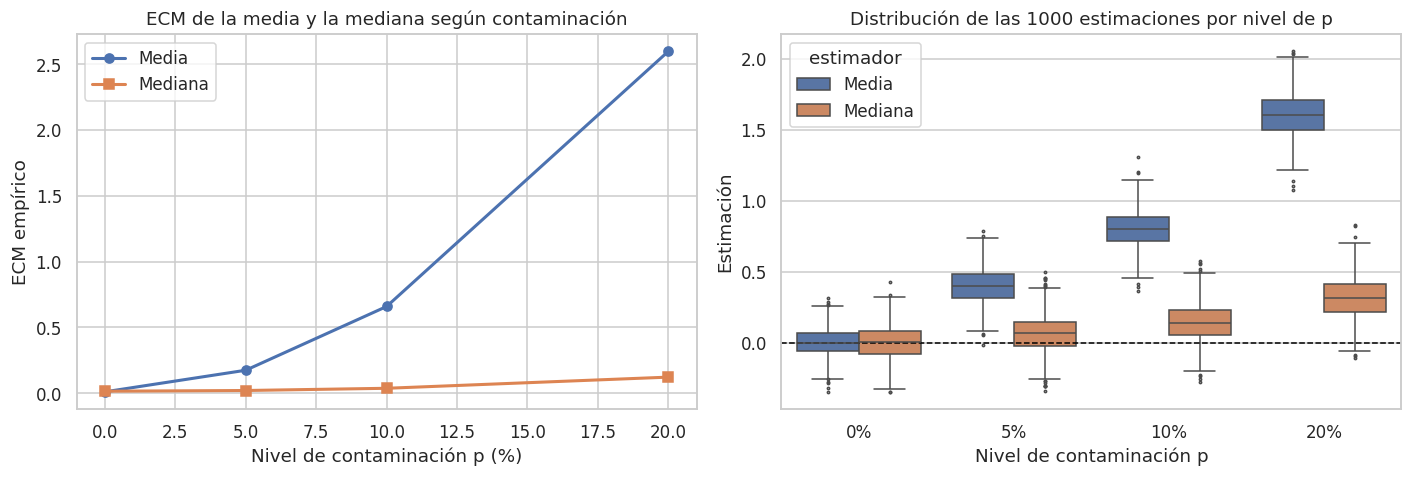

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel izquierdo: ECM vs nivel de contaminación (el gráfico más directo para
# responder "a partir de qué p gana la mediana")
axes[0].plot(tabla_1_1["p"] * 100, tabla_1_1["ecm_media"], "o-", label="Media", linewidth=2)
axes[0].plot(tabla_1_1["p"] * 100, tabla_1_1["ecm_mediana"], "s-", label="Mediana", linewidth=2)
axes[0].set_xlabel("Nivel de contaminación p (%)")
axes[0].set_ylabel("ECM empírico")
axes[0].set_title("ECM de la media y la mediana según contaminación")
axes[0].legend()

# Panel derecho: distribución completa de cada estimador por nivel de p
data_box = []
for p in niveles_p:
    medias, medianas = dist_1_1[p]
    for v in medias:
        data_box.append({"p": f"{int(p*100)}%", "estimador": "Media", "valor": v})
    for v in medianas:
        data_box.append({"p": f"{int(p*100)}%", "estimador": "Mediana", "valor": v})
df_box = pd.DataFrame(data_box)
sns.boxplot(data=df_box, x="p", y="valor", hue="estimador", ax=axes[1], fliersize=1.5)
axes[1].axhline(mu0, color="black", linestyle="--", linewidth=1, label="valor verdadero")
axes[1].set_xlabel("Nivel de contaminación p")
axes[1].set_ylabel("Estimación")
axes[1].set_title("Distribución de las 1000 estimaciones por nivel de p")

plt.tight_layout()
plt.show()

**¿A partir de qué nivel de contaminación gana la mediana?** Con $p=0\%$ la media
es más eficiente (menor ECM) que la mediana, tal como predice la teoría: bajo
normalidad pura, la media es el estimador de máxima verosimilitud y la mediana paga
un costo de eficiencia (~57% más ECM) por no usar toda la información muestral. Pero
apenas aparece un 5% de contaminación con outliers grandes, la media se dispara: su
ECM se multiplica casi por 18, mientras que el de la mediana apenas se duplica. A
partir de ese punto la mediana domina en todos los niveles evaluados, y la ventaja
se agranda con $p$.

#### Interpretación económica — Parte 1.1
Esto no es un tecnicismo estadístico: es el argumento de fondo detrás de por qué en
macro y en micro casi nunca reportamos el ingreso *medio* de un país o de un hogar
sino el *mediano*. El ingreso, el patrimonio o el tamaño de las empresas tienen colas
pesadas —unos pocos valores extremos (multimillonarios, empresas gigantes, un dato
mal cargado)— y ese puñado de observaciones "contamina" la media igual que en esta
simulación. Con apenas 5% de datos atípicos la media deja de ser un buen resumen de
"lo típico"; la mediana, en cambio, es insensible a *cuán* extremo es el outlier,
solo le importa su posición relativa. La lección general es de bias-variance
trade-off aplicado a robustez: cuando el modelo generador es exactamente el
supuesto (Gaussiano puro), conviene el estimador eficiente (media); apenas el
supuesto se rompe, conviene sacrificar algo de eficiencia por robustez.

## 1.2 Regresión lineal bajo contaminación

Ahora contaminamos el término de error de un modelo $y = \beta_0 + \beta_1 x + \varepsilon$
y comparamos dos estimadores de $\beta_1$: MCO calculado "a mano" con la fórmula
matricial $\hat\beta = (X'X)^{-1}X'y$, y LAD (*Least Absolute Deviations*), que
minimiza $\sum_i |e_i|$ numéricamente con `scipy.optimize.minimize`.

In [ ]:
def generar_datos_regresion(n, p, beta0, beta1, sigma0, mu1, sigma1, rng):
    """Genera (x, y) de un modelo lineal simple, contaminando una fracción p
    de los errores con una N(mu1, sigma1^2) en lugar de N(0, sigma0^2)."""
    x = rng.normal(0, 2, n)
    n_out = int(round(n * p))
    n_clean = n - n_out
    eps_limpio = rng.normal(0, sigma0, n_clean)
    eps_outlier = rng.normal(mu1, sigma1, n_out)
    eps = np.concatenate([eps_limpio, eps_outlier])
    rng.shuffle(eps)
    y = beta0 + beta1 * x + eps
    return x, y


def ols_a_mano(x, y):
    """MCO vía álgebra matricial: beta_hat = (X'X)^{-1} X'y. Sin statsmodels/sklearn."""
    X = np.column_stack([np.ones_like(x), x])
    return np.linalg.inv(X.T @ X) @ X.T @ y


def lad(x, y):
    """Least Absolute Deviations: minimiza la suma de residuos absolutos."""
    X = np.column_stack([np.ones_like(x), x])
    beta_inicial = ols_a_mano(x, y)  # arranca del óptimo de MCO
    resultado = minimize(
        lambda b: np.sum(np.abs(y - X @ b)), x0=beta_inicial, method="Nelder-Mead"
    )
    return resultado.x

In [ ]:
beta0_true, beta1_true = 2.0, 1.5
sigma0_r = 1.0          # desvío del error "limpio"
mu1_r, sigma1_r = 15.0, 5.0   # error contaminante: grandes outliers
n_r, M_r = 100, 500

filas2 = []
dist_1_2 = {}

for p in niveles_p:
    b1_ols = np.empty(M_r)
    b1_lad = np.empty(M_r)
    for m in range(M_r):
        x, y = generar_datos_regresion(n_r, p, beta0_true, beta1_true, sigma0_r, mu1_r, sigma1_r, rng)
        b1_ols[m] = ols_a_mano(x, y)[1]
        b1_lad[m] = lad(x, y)[1]
    sesgo_ols, ecm_ols = sesgo_ecm(b1_ols, beta1_true)
    sesgo_lad, ecm_lad = sesgo_ecm(b1_lad, beta1_true)
    filas2.append([p, sesgo_ols, ecm_ols, sesgo_lad, ecm_lad])
    dist_1_2[p] = (b1_ols, b1_lad)

tabla_1_2 = pd.DataFrame(
    filas2, columns=["p", "sesgo_ols", "ecm_ols", "sesgo_lad", "ecm_lad"]
)
tabla_1_2

,p,sesgo_ols,ecm_ols,sesgo_lad,ecm_lad
0,0.0000,-0.0014,0.0027,-0.0029,0.0040
1,0.0500,0.0097,0.0346,-0.0002,0.0043
2,0.1000,-0.0030,0.0570,-0.0004,0.0048
3,0.2000,0.0134,0.1150,-0.0006,0.0075


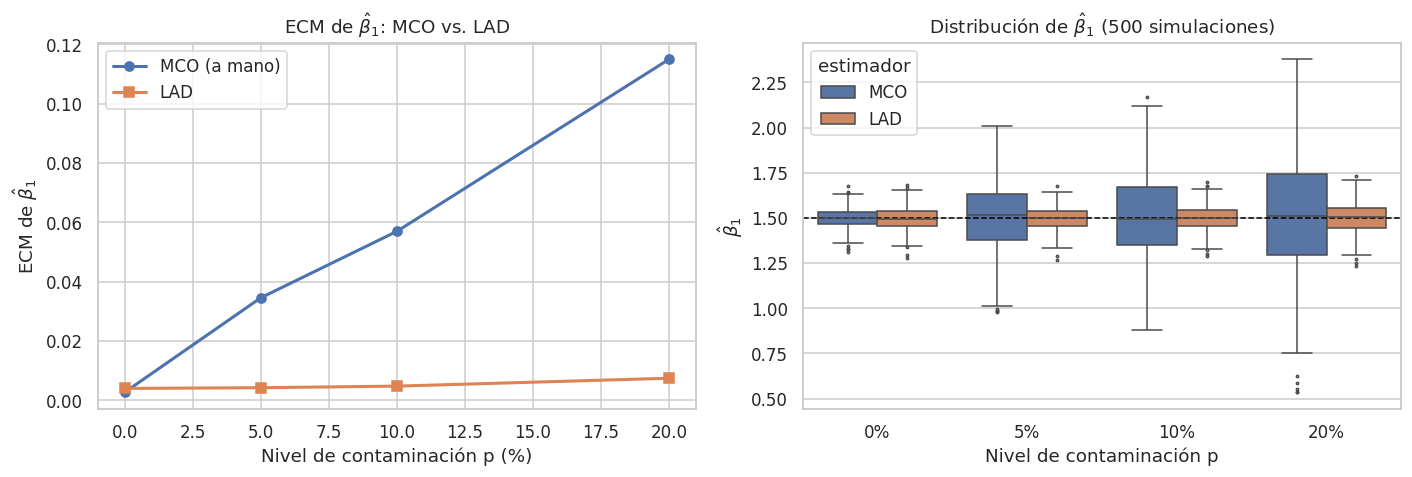

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(tabla_1_2["p"] * 100, tabla_1_2["ecm_ols"], "o-", label="MCO (a mano)", linewidth=2)
axes[0].plot(tabla_1_2["p"] * 100, tabla_1_2["ecm_lad"], "s-", label="LAD", linewidth=2)
axes[0].set_xlabel("Nivel de contaminación p (%)")
axes[0].set_ylabel(r"ECM de $\hat{\beta}_1$")
axes[0].set_title(r"ECM de $\hat{\beta}_1$: MCO vs. LAD")
axes[0].legend()

data_box2 = []
for p in niveles_p:
    b1_ols, b1_lad = dist_1_2[p]
    for v in b1_ols:
        data_box2.append({"p": f"{int(p*100)}%", "estimador": "MCO", "valor": v})
    for v in b1_lad:
        data_box2.append({"p": f"{int(p*100)}%", "estimador": "LAD", "valor": v})
df_box2 = pd.DataFrame(data_box2)
sns.boxplot(data=df_box2, x="p", y="valor", hue="estimador", ax=axes[1], fliersize=1.5)
axes[1].axhline(beta1_true, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Nivel de contaminación p")
axes[1].set_ylabel(r"$\hat{\beta}_1$")
axes[1].set_title(r"Distribución de $\hat{\beta}_1$ (500 simulaciones)")

plt.tight_layout()
plt.show()

#### Interpretación económica — Parte 1.2
Acá el resultado es distinto al de 1.1 y por eso es interesante: como los outliers
entran por el término de error y son **independientes de $x$**, MCO sigue siendo
insesgado en la pendiente (el sesgo se mantiene cerca de cero en todos los niveles
de $p$). Lo que se rompe no es la insesgadez sino la **eficiencia**: la varianza
(y por lo tanto el ECM) de $\hat\beta_1^{MCO}$ crece muy rápido con la contaminación,
porque MCO minimiza errores al cuadrado y un puñado de residuos gigantes domina la
suma. LAD, al minimizar valores absolutos, penaliza mucho menos esos residuos
extremos y mantiene un ECM casi plano en todo el rango. En la práctica, esto es
exactamente el motivo por el que en econometría aplicada con datos con "errores de
medición" gruesos (encuestas de hogares, datos administrativos con valores mal
cargados) conviene al menos reportar una regresión de cuantiles o LAD como chequeo
de robustez del coeficiente estimado por MCO: si ambos coinciden, hay más confianza
en el resultado; si difieren mucho, probablemente hay outliers influyentes
dominando la estimación por mínimos cuadrados.

---
# Parte 2 — Paradoja de Simpson y variables omitidas

## 2.1 Construcción del modelo

Construimos un proceso generador de datos (DGP) donde el efecto **directo** de $X$
sobre $Y$ es exactamente cero, pero $X$ está correlacionada con dos variables
categóricas $Z, W \in \{1,2,3,4\}$ que sí afectan a $Y$: $Z$ está *positivamente*
correlacionada con $X$ y $W$ está *negativamente* correlacionada con $X$, y ambas
tienen efecto positivo sobre $Y$. Esto genera sesgos de variable omitida de signo
opuesto que se cancelan en la regresión marginal, pero que aparecen con signos
opuestos al controlar por una sola de las dos variables.

In [ ]:
def digitalizar_en_4_niveles(v):
    """Discretiza un vector continuo en 4 niveles {1,2,3,4} usando cuartiles."""
    cortes = np.quantile(v, [0.25, 0.5, 0.75])
    return np.digitize(v, cortes) + 1


def generar_datos_ovb(n, rng):
    """DGP: beta_X verdadero = 0. Z correlaciona + con X, W correlaciona - con X.
    Ambas Z y W tienen efecto positivo y del mismo tamaño sobre Y."""
    X = rng.normal(0, 1, n)
    Z = digitalizar_en_4_niveles(1.2 * X + rng.normal(0, 1, n))
    W = digitalizar_en_4_niveles(-1.2 * X + rng.normal(0, 1, n))
    ruido = rng.normal(0, 1, n)
    beta_Z, beta_W = 1.3, 1.3
    Y = beta_Z * Z + beta_W * W + ruido
    return pd.DataFrame({"X": X, "Y": Y, "Z": Z, "W": W})


def beta_X_de(especificacion, df):
    """Corre Y ~ especificacion (siempre incluye X) y devuelve (coef_X, p-valor)."""
    modelo = sm.OLS(df["Y"], sm.add_constant(df[especificacion])).fit()
    return modelo.params["X"], modelo.pvalues["X"]

In [ ]:
# Una corrida ilustrativa con muestra grande para ver los tres coeficientes con precisión
df_demo = generar_datos_ovb(2000, rng)

b1, p1 = beta_X_de(["X"], df_demo)
b2, p2 = beta_X_de(["X", "Z"], df_demo)
b3, p3 = beta_X_de(["X", "W"], df_demo)

resumen_demo = pd.DataFrame({
    "especificación": ["Y ~ X (marginal)", "Y ~ X + Z", "Y ~ X + W"],
    "beta_X_hat": [b1, b2, b3],
    "p-valor": [p1, p2, p3],
})
resumen_demo

,especificación,beta_X_hat,p-valor
0,Y ~ X (marginal),0.0265,0.4907
1,Y ~ X + Z,-0.9459,0.0000
2,Y ~ X + W,0.9870,0.0000


In [ ]:
# M = 1000 simulaciones: distribución de beta_X_hat bajo las tres especificaciones
especificaciones = {
    "Sin controles (Y~X)": ["X"],
    "Con Z (Y~X+Z)": ["X", "Z"],
    "Con W (Y~X+W)": ["X", "W"],
}
M2, n2 = 1000, 300
dist_2 = {nombre: np.empty(M2) for nombre in especificaciones}

for m in range(M2):
    df_ = generar_datos_ovb(n2, rng)
    for nombre, vars_ in especificaciones.items():
        dist_2[nombre][m] = beta_X_de(vars_, df_)[0]

resumen_dist_2 = pd.DataFrame({
    "especificación": list(dist_2.keys()),
    "media(beta_X_hat)": [np.mean(v) for v in dist_2.values()],
    "sd(beta_X_hat)": [np.std(v) for v in dist_2.values()],
})
resumen_dist_2

,especificación,media(beta_X_hat),sd(beta_X_hat)
0,Sin controles (Y~X),-0.0038,0.0769
1,Con Z (Y~X+Z),-1.0045,0.1198
2,Con W (Y~X+W),0.9943,0.1132


In [ ]:
# ¿El sesgo desaparece con muestras grandes? Comparamos la especificación marginal
# (no debería tener sesgo, por construcción simétrica) contra la que omite W
# (que debería mantenerse sesgada) a medida que crece n.
tamanos_n = [100, 1000, 10_000, 100_000]
persistencia = []
for n_ in tamanos_n:
    reps = 100 if n_ < 100_000 else 30
    est_sin = np.array([beta_X_de(["X"], generar_datos_ovb(n_, rng))[0] for _ in range(reps)])
    est_conZ = np.array([beta_X_de(["X", "Z"], generar_datos_ovb(n_, rng))[0] for _ in range(reps)])
    persistencia.append({
        "n": n_,
        "media_sin_controles": np.mean(est_sin), "sd_sin_controles": np.std(est_sin),
        "media_con_Z_omite_W": np.mean(est_conZ), "sd_con_Z_omite_W": np.std(est_conZ),
    })
tabla_persistencia = pd.DataFrame(persistencia)
tabla_persistencia

,n,media_sin_controles,sd_sin_controles,media_con_Z_omite_W,sd_con_Z_omite_W
0,100,-0.0158,0.1335,-0.9928,0.2113
1,1000,-0.0033,0.0387,-0.9943,0.0560
2,10000,0.0003,0.0121,-1.0001,0.0198
3,100000,0.0004,0.0037,-0.9979,0.0053


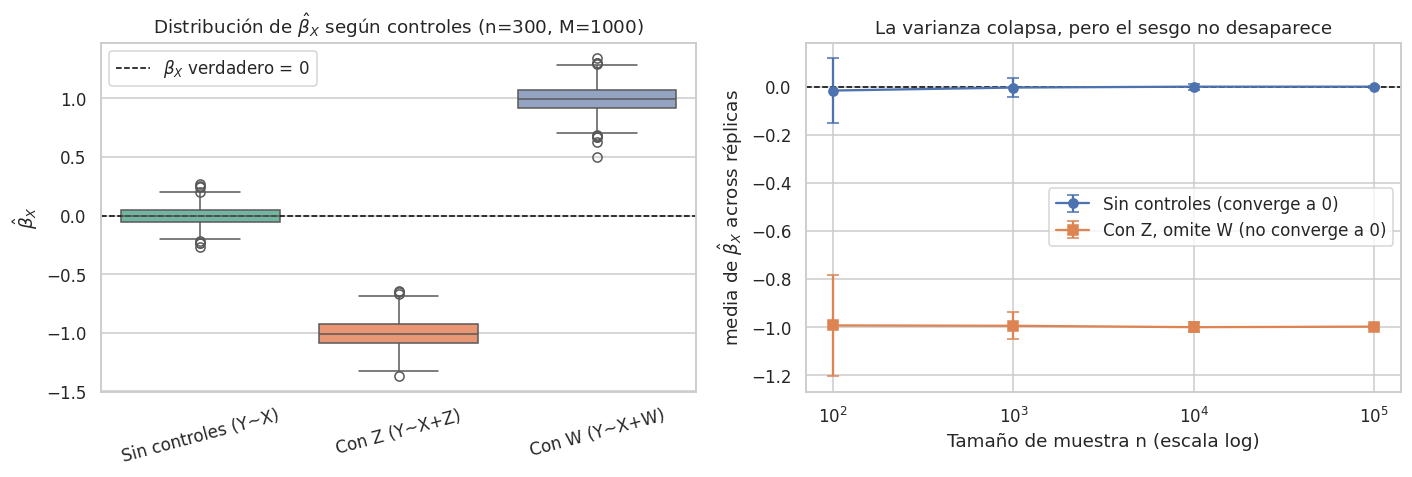

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel izquierdo: distribución de beta_X_hat bajo las tres especificaciones (n=300)
data_v = pd.DataFrame({k: v for k, v in dist_2.items()})
sns.boxplot(data=data_v, ax=axes[0], palette="Set2")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1, label=r"$\beta_X$ verdadero = 0")
axes[0].set_ylabel(r"$\hat{\beta}_X$")
axes[0].set_title(r"Distribución de $\hat{\beta}_X$ según controles (n=300, M=1000)")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=15)

# Panel derecho: persistencia del sesgo con n creciente (escala log en x)
axes[1].errorbar(tabla_persistencia["n"], tabla_persistencia["media_sin_controles"],
                  yerr=tabla_persistencia["sd_sin_controles"], fmt="o-",
                  label="Sin controles (converge a 0)", capsize=4)
axes[1].errorbar(tabla_persistencia["n"], tabla_persistencia["media_con_Z_omite_W"],
                  yerr=tabla_persistencia["sd_con_Z_omite_W"], fmt="s-",
                  label="Con Z, omite W (no converge a 0)", capsize=4)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xscale("log")
axes[1].set_xlabel("Tamaño de muestra n (escala log)")
axes[1].set_ylabel(r"media de $\hat{\beta}_X$ across réplicas")
axes[1].set_title("La varianza colapsa, pero el sesgo no desaparece")
axes[1].legend()

plt.tight_layout()
plt.show()

**¿El sesgo desaparece con $n$ grande?** No. En el panel derecho se ve con
claridad: al aumentar $n$ de 100 a 100.000, el desvío estándar de $\hat\beta_X$ (con
$Z$ como único control, omitiendo $W$) se achica casi 40 veces —tal como predice la
teoría asintótica, la varianza cae a razón $1/n$— pero la **media** de esas
estimaciones se queda clavada en $\approx -1$, lejísimos del verdadero $\beta_X=0$.
Es la firma de un estimador **inconsistente**: converge en probabilidad, pero converge
al valor equivocado (un "pseudo-parámetro" contaminado por la variable omitida), no
al verdadero. Ningún tamaño de muestra arregla eso, porque el problema no es de
ruido muestral sino de identificación: la especificación misma está mal. En cambio,
la especificación marginal (que omite tanto $Z$ como $W$) sí converge a 0, porque en
este DGP diseñamos los sesgos de $Z$ y $W$ para que se cancelen exactamente entre sí.

## 2.2 Ilustración de la Paradoja de Simpson

Tomamos una única muestra y graficamos $Y$ contra $X$, coloreando por $Z$. Ajustamos
una recta de regresión *dentro* de cada grupo de $Z$ y la comparamos con la recta de
regresión *marginal* (agrupando todos los puntos, ignorando $Z$).

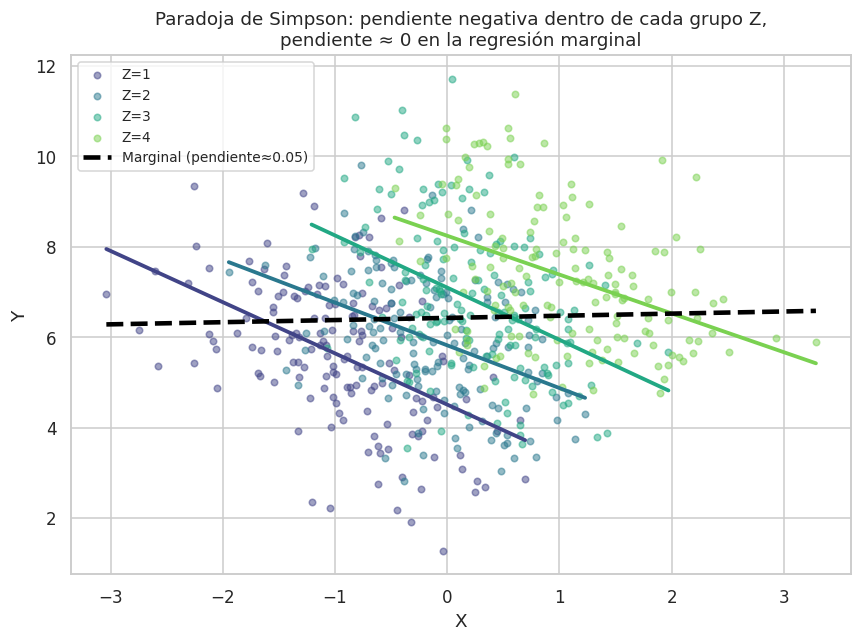

In [ ]:
df_ilustracion = generar_datos_ovb(600, rng)

fig, ax = plt.subplots(figsize=(8, 6))
paleta = sns.color_palette("viridis", 4)

for i, z in enumerate(sorted(df_ilustracion["Z"].unique())):
    sub = df_ilustracion[df_ilustracion["Z"] == z]
    ax.scatter(sub["X"], sub["Y"], color=paleta[i], alpha=0.5, s=18, label=f"Z={z}")
    b0z, b1z = ols_a_mano(sub["X"].values, sub["Y"].values)
    xs = np.linspace(sub["X"].min(), sub["X"].max(), 50)
    ax.plot(xs, b0z + b1z * xs, color=paleta[i], linewidth=2.5)

# recta marginal (todos los puntos juntos, ignorando Z)
b0_m, b1_m = ols_a_mano(df_ilustracion["X"].values, df_ilustracion["Y"].values)
xs_full = np.linspace(df_ilustracion["X"].min(), df_ilustracion["X"].max(), 50)
ax.plot(xs_full, b0_m + b1_m * xs_full, color="black", linewidth=3, linestyle="--",
        label=f"Marginal (pendiente≈{b1_m:.2f})")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Paradoja de Simpson: pendiente negativa dentro de cada grupo Z,\npendiente ≈ 0 en la regresión marginal")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

#### Interpretación económica — Parte 2
Este ejercicio es, en el fondo, sobre qué significa "controlar por" algo en una
regresión y por qué la elección de controles no es un detalle técnico sino una
decisión sobre qué historia causal se está contando. Con la variable $Z$ como único
control, el modelo dice que $X$ tiene un efecto *negativo* sobre $Y$; con $W$ como
único control, dice que tiene un efecto *positivo*; y sin controles, dice que no
tiene ningún efecto. Los tres resultados sobre la *misma* variable de interés surgen
exclusivamente de qué omitimos, no de ningún cambio en la relación verdadera (que es
nula por construcción). En un caso real —pensemos en estimar el efecto de años de
educación ($X$) sobre el salario ($Y$), donde $Z$ podría ser la ocupación y $W$ la
región geográfica— el investigador podría convencerse de un efecto positivo, negativo
o nulo únicamente por la especificación elegida, sin que el mundo haya cambiado en lo
más mínimo. La paradoja de Simpson es la versión visual y extrema de esto: agrupar o
no agrupar por una tercera variable puede invertir literalmente el signo del
coeficiente. La conclusión práctica es que la robustez de un resultado econométrico
debe evaluarse mostrando *cómo cambia* el coeficiente de interés a medida que se
agregan controles teóricamente justificados, no reportando una única especificación
como si fuera la verdad revelada.

---
# Parte 3 — Análisis empírico con Gapminder: Paraguay

Usamos el dataset Gapminder (incluido en `plotly.express.data.gapminder()`, con
observaciones cada 5 años entre 1952 y 2007 para 142 países) y elegimos **Paraguay**
como país de análisis.

In [ ]:
df_gap = px.data.gapminder()
pais = "Paraguay"
continente = df_gap.loc[df_gap.country == pais, "continent"].iloc[0]
print(f"País elegido: {pais} | Continente (según Gapminder): {continente}")
df_gap[df_gap.country == pais][["year", "lifeExp", "pop", "gdpPercap"]]

País elegido: Paraguay | Continente (según Gapminder): Americas


,year,lifeExp,pop,gdpPercap
1188,1952,62.6490,1555876,"1,952.3087"
1189,1957,63.1960,1770902,"2,046.1547"
1190,1962,64.3610,2009813,"2,148.0271"
1191,1967,64.9510,2287985,"2,299.3763"
1192,1972,65.8150,2614104,"2,523.3380"
1193,1977,66.3530,2984494,"3,248.3733"
1194,1982,66.8740,3366439,"4,258.5036"
1195,1987,67.3780,3886512,"3,998.8757"
1196,1992,68.2250,4483945,"4,196.4111"
1197,1997,69.4000,5154123,"4,247.4003"


## Pregunta A — Convergencia en esperanza de vida

¿Convergió Paraguay hacia el promedio mundial de esperanza de vida entre 1952 y 2007,
o la brecha se mantuvo? Calculamos, para cada año, la brecha entre la esperanza de
vida de Paraguay y el promedio mundial (simple, entre los 142 países del dataset).

In [ ]:
prom_mundial = df_gap.groupby("year")["lifeExp"].mean().rename("lifeExp_mundial")
serie_pais = df_gap[df_gap.country == pais].set_index("year")["lifeExp"].rename("lifeExp_pais")
tabla_a = pd.concat([serie_pais, prom_mundial], axis=1)
tabla_a["brecha"] = tabla_a["lifeExp_pais"] - tabla_a["lifeExp_mundial"]
tabla_a

,lifeExp_pais,lifeExp_mundial,brecha
year,,,
1952,62.6490,49.0576,13.5914
1957,63.1960,51.5074,11.6886
1962,64.3610,53.6092,10.7518
1967,64.9510,55.6783,9.2727
1972,65.8150,57.6474,8.1676
1977,66.3530,59.5702,6.7828
1982,66.8740,61.5332,5.3408
1987,67.3780,63.2126,4.1654
1992,68.2250,64.1603,4.0647


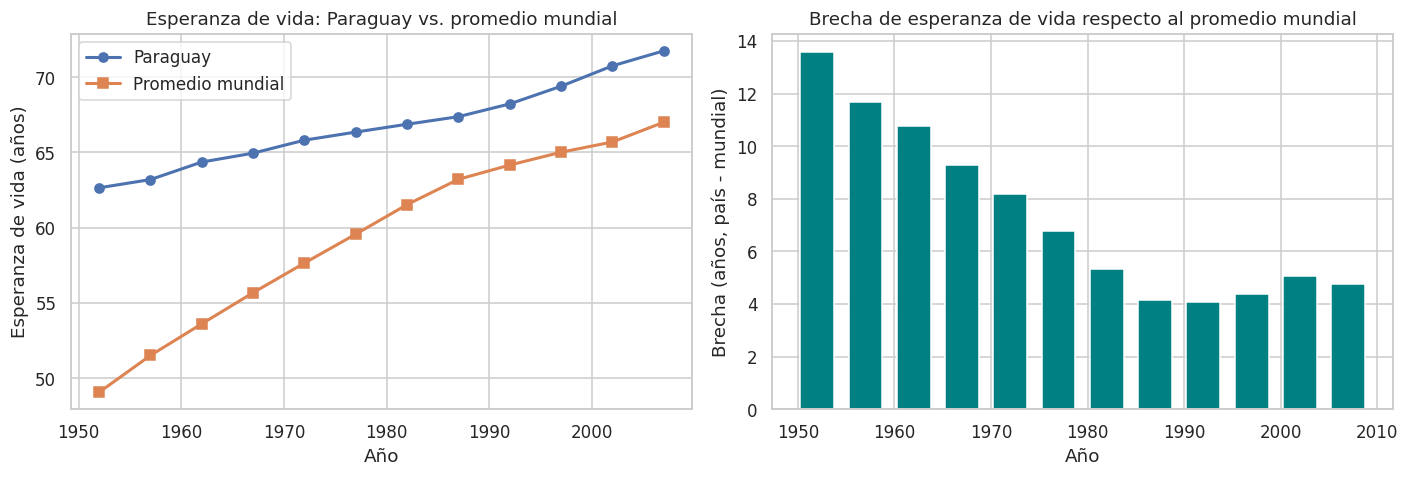

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(tabla_a.index, tabla_a["lifeExp_pais"], "o-", label=pais, linewidth=2)
axes[0].plot(tabla_a.index, tabla_a["lifeExp_mundial"], "s-", label="Promedio mundial", linewidth=2)
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Esperanza de vida (años)")
axes[0].set_title(f"Esperanza de vida: {pais} vs. promedio mundial")
axes[0].legend()

axes[1].bar(tabla_a.index, tabla_a["brecha"], width=3.5, color="teal")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Brecha (años, país - mundial)")
axes[1].set_title("Brecha de esperanza de vida respecto al promedio mundial")
axes[1].axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

**Respuesta A:** hay convergencia, pero es parcial y se frena. En 1952 Paraguay
tenía una esperanza de vida 13,6 años por encima del promedio mundial (62,6 vs. 49,1):
el país arrancaba la serie *mejor* que el promedio global de la época, dominado por
los bajísimos niveles de África y Asia de posguerra. A medida que el resto del mundo
—sobre todo Asia— gana esperanza de vida a un ritmo mucho más acelerado, la brecha se
achica de forma casi monótona hasta 1992, cuando llega a un mínimo de 4,1 años. De ahí
en adelante la brecha deja de achicarse y se estabiliza (e incluso repunta levemente)
entre 4 y 5 años hacia 2007. No es que Paraguay haya dejado de mejorar —la esperanza
de vida pasó de 62,6 a 71,8 años en el período—, sino que el promedio mundial, traccionado
por el catch-up asiático, mejoró a un ritmo similar en las últimas dos décadas de la
serie. En definitiva: convergencia fuerte 1952-1992, convergencia estancada 1992-2007.

## Pregunta B — Atipicidad respecto al continente

¿Hubo algún período en que Paraguay tuvo una trayectoria de desarrollo atípica
respecto al promedio de su continente? Usamos el PBI per cápita (`gdpPercap`) como
indicador de desarrollo y comparamos a Paraguay contra el promedio del continente que
le asigna Gapminder (*Americas*, que en este dataset agrupa a todo el continente
americano, de Canadá a Argentina).

In [ ]:
prom_continente = (
    df_gap[df_gap.continent == continente].groupby("year")["gdpPercap"].mean().rename("gdp_continente")
)
serie_gdp_pais = df_gap[df_gap.country == pais].set_index("year")["gdpPercap"].rename("gdp_pais")
tabla_b = pd.concat([serie_gdp_pais, prom_continente], axis=1)
tabla_b["desvio_pct"] = (tabla_b["gdp_pais"] / tabla_b["gdp_continente"] - 1) * 100
tabla_b["crecim_pais_pct"] = tabla_b["gdp_pais"].pct_change() * 100
tabla_b["crecim_continente_pct"] = tabla_b["gdp_continente"].pct_change() * 100
tabla_b["diferencial_crecim"] = tabla_b["crecim_pais_pct"] - tabla_b["crecim_continente_pct"]
tabla_b

,gdp_pais,gdp_continente,desvio_pct,crecim_pais_pct,crecim_continente_pct,diferencial_crecim
year,,,,,,
1952,"1,952.3087","4,079.0626",-52.1383,NaN,NaN,NaN
1957,"2,046.1547","4,616.0437",-55.6730,4.8069,13.1643,-8.3574
1962,"2,148.0271","4,901.5419",-56.1765,4.9787,6.1849,-1.2062
1967,"2,299.3763","5,668.2535",-59.4341,7.0460,15.6423,-8.5963
1972,"2,523.3380","6,491.3341",-61.1276,9.7401,14.5209,-4.7808
1977,"3,248.3733","7,352.0071",-55.8165,28.7332,13.2588,15.4744
1982,"4,258.5036","7,506.7371",-43.2709,31.0965,2.1046,28.9919
1987,"3,998.8757","7,793.4003",-48.6889,-6.0967,3.8187,-9.9154
1992,"4,196.4111","8,044.9344",-47.8378,4.9398,3.2275,1.7122


In [ ]:
periodo_max = tabla_b["diferencial_crecim"].idxmax()
print(f"Período con mayor sobre-desempeño relativo (mayor diferencial de crecimiento): {periodo_max}")
print(f"Diferencial de crecimiento en ese período: {tabla_b.loc[periodo_max, 'diferencial_crecim']:.1f} p.p.")
print()
print("Diferenciales de crecimiento por período (país - continente), en p.p.:")
print(tabla_b['diferencial_crecim'].round(1))

Período con mayor sobre-desempeño relativo (mayor diferencial de crecimiento): 1982
Diferencial de crecimiento en ese período: 29.0 p.p.

Diferenciales de crecimiento por período (país - continente), en p.p.:
year
1952        NaN
1957    -8.4000
1962    -1.2000
1967    -8.6000
1972    -4.8000
1977    15.5000
1982    29.0000
1987    -9.9000
1992     1.7000
1997    -9.3000
2002   -15.4000
2007    -8.2000
Name: diferencial_crecim, dtype: float64


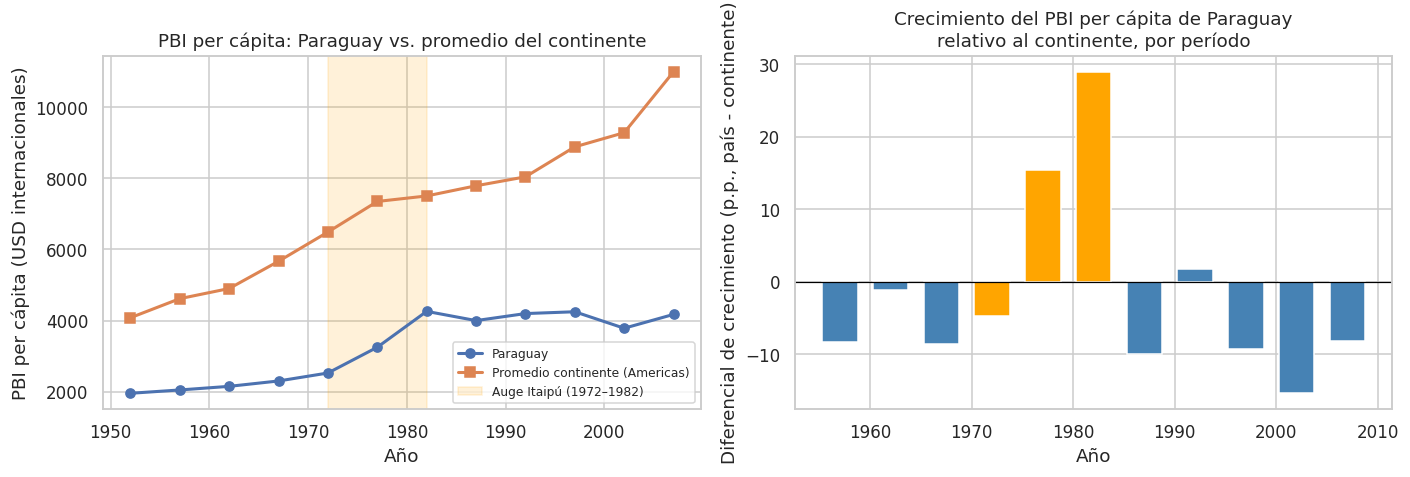

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(tabla_b.index, tabla_b["gdp_pais"], "o-", label=pais, linewidth=2)
axes[0].plot(tabla_b.index, tabla_b["gdp_continente"], "s-", label="Promedio continente (Americas)", linewidth=2)
axes[0].axvspan(1972, 1982, color="orange", alpha=0.15, label="Auge Itaipú (1972–1982)")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("PBI per cápita (USD internacionales)")
axes[0].set_title(f"PBI per cápita: {pais} vs. promedio del continente")
axes[0].legend(fontsize=8)

colores = ["orange" if 1972 <= y <= 1982 else "steelblue" for y in tabla_b.index]
axes[1].bar(tabla_b.index, tabla_b["diferencial_crecim"], width=3.5, color=colores)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Diferencial de crecimiento (p.p., país - continente)")
axes[1].set_title("Crecimiento del PBI per cápita de Paraguay\nrelativo al continente, por período")

plt.tight_layout()
plt.show()

**Respuesta B:** el período claramente atípico es **1972–1982**, con epicentro
en 1977–1982. En esos dos períodos el PBI per cápita de Paraguay creció 28,7% y 31,1%
respectivamente entre observaciones consecutivas del dataset (equivalente a tasas
anuales muy por encima del 6-8%), mientras el continente en su conjunto crecía a un
ritmo mucho más moderado (13,3% y apenas 2,1%). El diferencial de crecimiento de
1977-1982 (+29 puntos porcentuales a favor de Paraguay) es, por lejos, el más grande
de toda la serie: ningún otro período se acerca. Inmediatamente después, entre 1982 y
1987, el PBI per cápita paraguayo *cae* 6,1% mientras el continente sigue creciendo —el
diferencial se da vuelta bruscamente.

**Vínculo histórico:** el período coincide, casi año por año, con la construcción de
la represa hidroeléctrica de Itaipú (obra binacional con Brasil), cuya fase de
construcción intensiva se ubica entre 1973 y 1982 y llegó a emplear decenas de miles
de trabajadores en simultáneo. Fuentes históricas y económicas describen esos años
como un boom de inversión y empleo en construcción que llevó el crecimiento del PBI
paraguayo a superar ampliamente su propio promedio histórico, seguido por una fuerte
desaceleración —incluso una "década perdida" en los años 80— una vez que la obra
concluyó y se combinó con la crisis de deuda regional. Es un caso de manual de
crecimiento impulsado por una gran inversión en infraestructura, con la fragilidad
típica de una economía chica: cuando el proyecto que traccionaba el PBI terminó, no
hubo un motor de crecimiento equivalente que lo reemplazara, y el diferencial contra
el continente se revirtió con la misma intensidad con la que había aparecido.

#### Interpretación económica — Parte 3 (síntesis)
Los dos hallazgos de esta parte cuentan, en realidad, la misma historia de país desde
ángulos distintos. En esperanza de vida —un indicador que depende sobre todo de salud
pública, agua potable, mortalidad infantil y nutrición— Paraguay convergió con el
mundo de forma bastante estable y sin sobresaltos, lo cual es consistente con que
estos indicadores mejoran de manera relativamente gradual y menos sensible a shocks de
corto plazo o a un único proyecto de inversión. En cambio, el PBI per cápita —una
variable de flujo, mucho más volátil y sensible a un shock de inversión puntual—
muestra un patrón completamente distinto: no hay convergencia gradual, sino un salto
abrupto y transitorio ligado a un evento específico (Itaipú) que después se revierte
casi por completo. La lección de fondo para cualquier análisis de "desarrollo" es que
distintos indicadores capturan procesos con dinámicas y horizontes temporales muy
distintos, y que un boom de PBI impulsado por una única obra de infraestructura no es,
por sí solo, evidencia de una transformación estructural sostenida de la economía —algo
que el propio dato de Paraguay confirma al desinflarse tan rápido como se infló.

---
## Conclusiones generales

1. **Robustez (Parte 1):** cuando el modelo generador coincide con el supuesto (sin
   contaminación), conviene el estimador eficiente (media, MCO). Apenas hay
   contaminación, la robustez (mediana, LAD) pasa a dominar en error cuadrático medio,
   aun cuando MCO siga siendo insesgado.
2. **Variables omitidas (Parte 2):** el signo y la significatividad de un coeficiente
   pueden depender por completo de qué variables se controlan, y ese sesgo **no**
   desaparece con muestras grandes: es un problema de identificación, no de tamaño
   muestral.
3. **Gapminder (Parte 3):** Paraguay convergió de forma sostenida en esperanza de vida
   entre 1952 y 2007, pero su trayectoria de PBI per cápita muestra un episodio
   claramente atípico (1972-1982) asociado a la construcción de Itaipú, seguido de una
   fuerte reversión — evidencia de que un boom de inversión puntual no garantiza una
   convergencia estructural de largo plazo.